# Data Cleaning

#### Handling the invalid zeros identified in notebook 01.
The strategy is to replace zeros with NaN then fill using 
the median — grouped by Outcome so we preserve the difference
between diabetic and non-diabetic patients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/diabetes.csv')
print(df.shape)

(768, 9)


## Step 1 — Replace Invalid Zeros with NaN

In [2]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after replacing zeros:")
print(df.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## Step 2 — Fill Missing Values

#### Using median grouped by Outcome (diabetic vs non-diabetic).
This way diabetic patients are filled with diabetic group median
and non-diabetic patients are filled with their own group median.
Simple mean/median imputation ignores this difference.

In [3]:
for col in cols_to_fix:
    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Step 3 — Verify the Fix

Checking that no zeros remain in the fixed columns and 
the distributions look reasonable.

In [4]:
print("Zeros remaining after cleaning:")
for col in cols_to_fix:
    print(f"  {col}: {(df[col] == 0).sum()}")

Zeros remaining after cleaning:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0


## Step 4 — Distribution Before vs After

Comparing how the distributions changed after imputation.

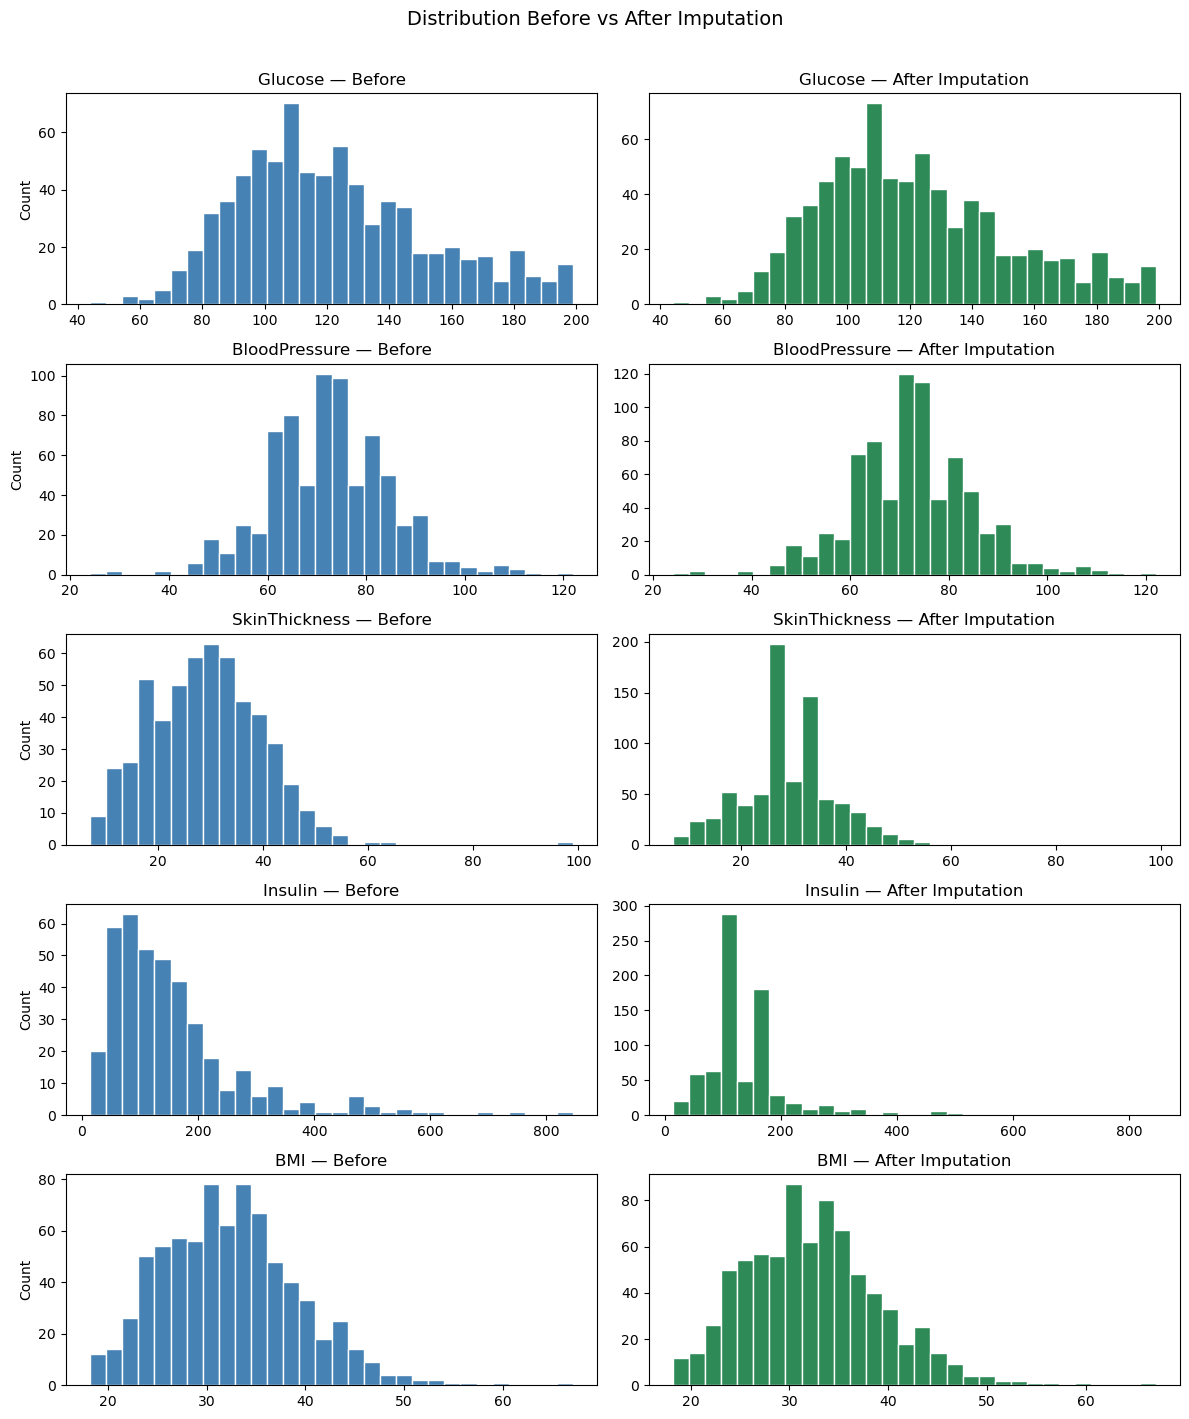

In [5]:
df_raw = pd.read_csv('../data/raw/diabetes.csv')
for col in cols_to_fix:
    df_raw[col] = df_raw[col].replace(0, np.nan)

fig, axes = plt.subplots(len(cols_to_fix), 2, figsize=(12, 14))

for i, col in enumerate(cols_to_fix):
    # before
    axes[i, 0].hist(df_raw[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Before')
    axes[i, 0].set_ylabel('Count')

    # after
    axes[i, 1].hist(df[col], bins=30, color='seagreen', edgecolor='white')
    axes[i, 1].set_title(f'{col} — After Imputation')

plt.suptitle('Distribution Before vs After Imputation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Save Cleaned Data

In [6]:
df.to_csv('../data/processed/diabetes_cleaned.csv', index=False)
print("Cleaned data saved.")
print(f"Shape: {df.shape}")
df.head()

Cleaned data saved.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
